In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df=pd.read_excel("Pumpkin_Seeds_Dataset.xlsx")

In [29]:
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,Çerçevelik


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               2500 non-null   int64  
 1   Perimeter          2500 non-null   float64
 2   Major_Axis_Length  2500 non-null   float64
 3   Minor_Axis_Length  2500 non-null   float64
 4   Convex_Area        2500 non-null   int64  
 5   Equiv_Diameter     2500 non-null   float64
 6   Eccentricity       2500 non-null   float64
 7   Solidity           2500 non-null   float64
 8   Extent             2500 non-null   float64
 9   Roundness          2500 non-null   float64
 10  Aspect_Ration      2500 non-null   float64
 11  Compactness        2500 non-null   float64
 12  Class              2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 254.0+ KB


In [31]:
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,80658.220800,1130.279015,456.601840,225.794921,81508.084400,319.334230,0.860879,0.989492,0.693205,0.791533,2.041702,0.704121
std,13664.510228,109.256418,56.235704,23.297245,13764.092788,26.891920,0.045167,0.003494,0.060914,0.055924,0.315997,0.053067
min,47939.000000,868.485000,320.844600,152.171800,48366.000000,247.058400,0.492100,0.918600,0.468000,0.554600,1.148700,0.560800
25%,70765.000000,1048.829750,414.957850,211.245925,71512.000000,300.167975,0.831700,0.988300,0.658900,0.751900,1.801050,0.663475
50%,79076.000000,1123.672000,449.496600,224.703100,79872.000000,317.305350,0.863700,0.990300,0.713050,0.797750,1.984200,0.707700
75%,89757.500000,1203.340500,492.737650,240.672875,90797.750000,338.057375,0.897025,0.991500,0.740225,0.834325,2.262075,0.743500
max,136574.000000,1559.450000,661.911300,305.818000,138384.000000,417.002900,0.948100,0.994400,0.829600,0.939600,3.144400,0.904900


In [32]:
df.shape

(2500, 13)

In [33]:
df["Class"].unique()

array(['Çerçevelik', 'Ürgüp Sivrisi'], dtype=object)

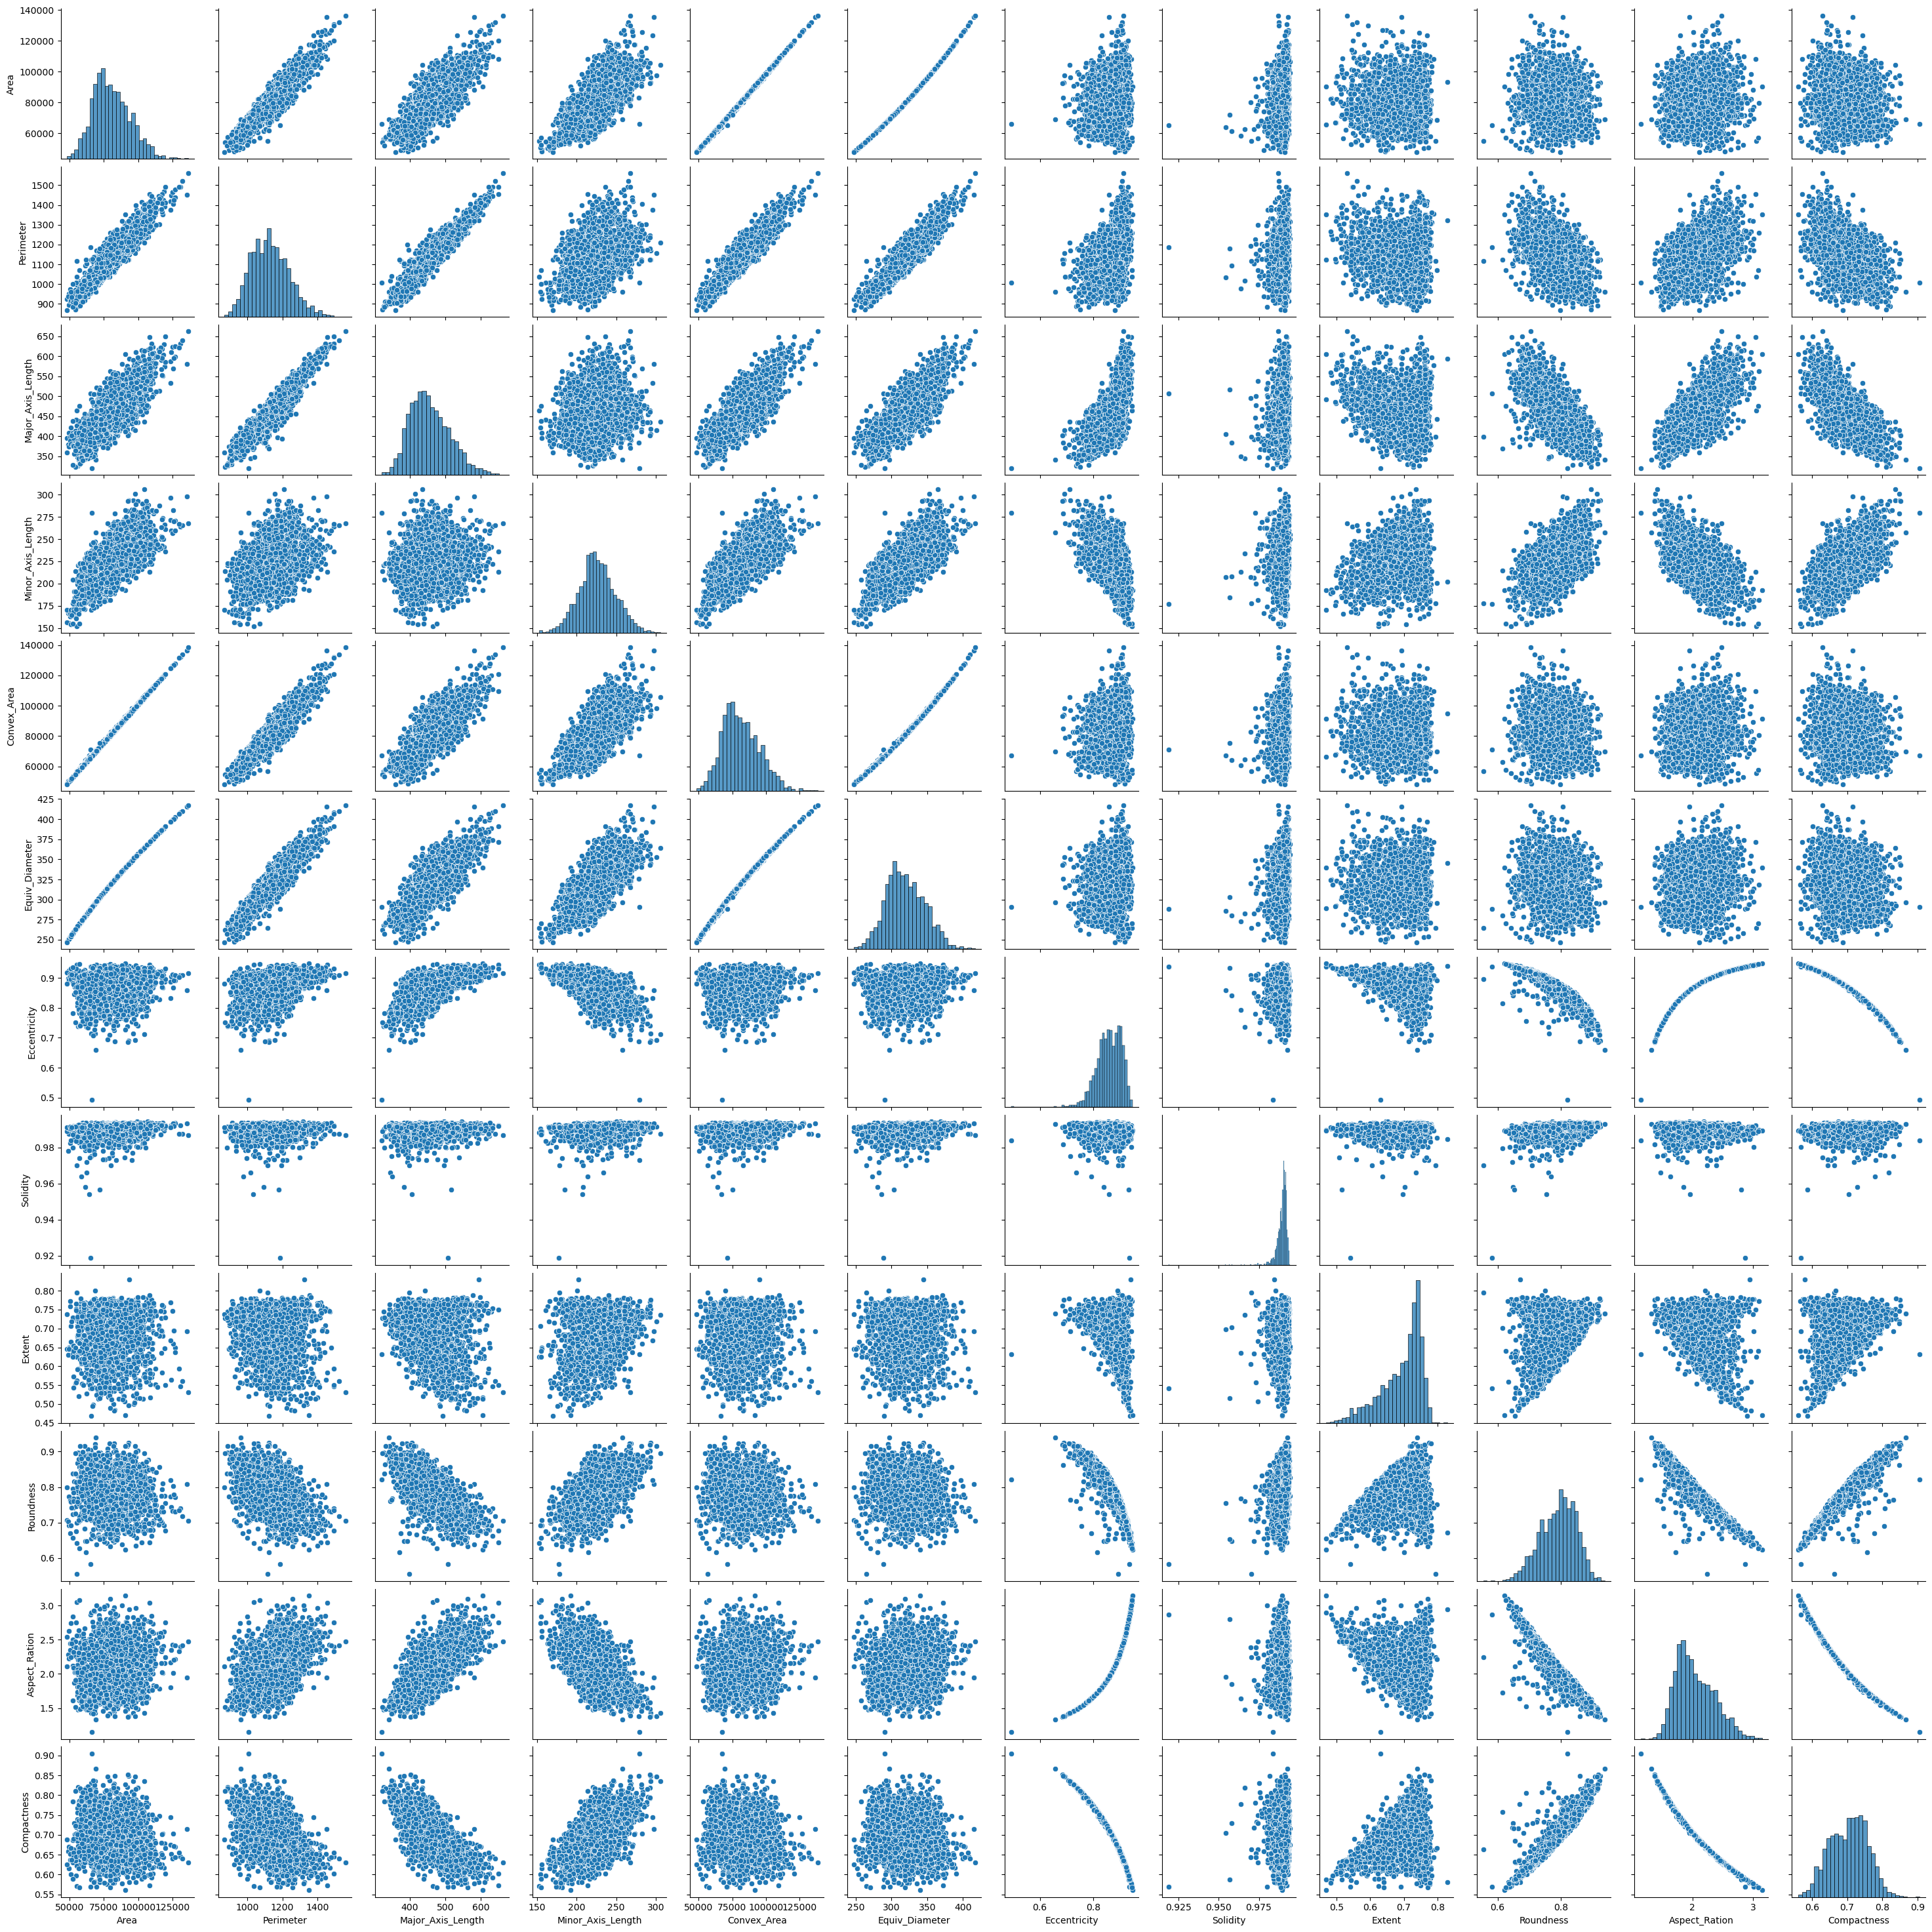

In [34]:
sns.pairplot(df)

In [35]:
X=df.drop("Class",axis=1)
y=df["Class"]

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=15)

In [38]:
#Encoding
from sklearn.preprocessing import LabelEncoder
label_encode=LabelEncoder()
y_train=label_encode.fit_transform(y_train)
y_test=label_encode.transform(y_test)

In [41]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [43]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

In [44]:
logistic=LogisticRegression()
logistic.fit(X_train,y_train)

LogisticRegression()

In [45]:
y_pred=logistic.predict(X_test)

In [46]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[367  31]
 [ 43 309]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       398
           1       0.91      0.88      0.89       352

    accuracy                           0.90       750
   macro avg       0.90      0.90      0.90       750
weighted avg       0.90      0.90      0.90       750



In [50]:
#hyperparameter
params={"penalty":["l1","l2","elasticnet"],
        "C":[0.01,0.1,1,10,100,1000],
        "solver":["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"],
        "class_weight":[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]}



In [51]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold

In [53]:
cv=StratifiedKFold()
grid=GridSearchCV(estimator=logistic,param_grid=params,cv=cv,n_jobs=-1)

In [54]:
grid.fit(X_train,y_train)
y_pred_hyper=grid.predict(X_test)
print(confusion_matrix(y_test,y_pred_hyper))
print(classification_report(y_test,y_pred_hyper))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max

[[370  28]
 [ 46 306]]
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       398
           1       0.92      0.87      0.89       352

    accuracy                           0.90       750
   macro avg       0.90      0.90      0.90       750
weighted avg       0.90      0.90      0.90       750



/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4800 fits failed out of a total of 8640.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
480 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1389,

In [55]:
grid.best_params_

{'C': 1000,
 'class_weight': {0: 100, 1: 100},
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [56]:
#SVC

In [62]:
from sklearn.svm import SVC
svc=SVC()

In [63]:
svc.fit(X_train,y_train)

SVC()

In [65]:
y_pred_svc=svc.predict(X_test)
print(confusion_matrix(y_test,y_pred_svc))
print(classification_report(y_test,y_pred_svc))

[[375  23]
 [ 48 304]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       398
           1       0.93      0.86      0.90       352

    accuracy                           0.91       750
   macro avg       0.91      0.90      0.90       750
weighted avg       0.91      0.91      0.91       750



In [66]:
svc=SVC(kernel="linear")
svc.fit(X_train,y_train)
y_pred_svc=svc.predict(X_test)
print(confusion_matrix(y_test,y_pred_svc))
print(classification_report(y_test,y_pred_svc))

[[370  28]
 [ 51 301]]
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       398
           1       0.91      0.86      0.88       352

    accuracy                           0.89       750
   macro avg       0.90      0.89      0.89       750
weighted avg       0.90      0.89      0.89       750



In [67]:
svc=SVC(kernel="poly")
svc.fit(X_train,y_train)
y_pred_svc=svc.predict(X_test)
print(confusion_matrix(y_test,y_pred_svc))
print(classification_report(y_test,y_pred_svc))

[[386  12]
 [ 89 263]]
              precision    recall  f1-score   support

           0       0.81      0.97      0.88       398
           1       0.96      0.75      0.84       352

    accuracy                           0.87       750
   macro avg       0.88      0.86      0.86       750
weighted avg       0.88      0.87      0.86       750



In [68]:
svc=SVC(kernel="sigmoid")
svc.fit(X_train,y_train)
y_pred_svc=svc.predict(X_test)
print(confusion_matrix(y_test,y_pred_svc))
print(classification_report(y_test,y_pred_svc))

[[300  98]
 [ 69 283]]
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       398
           1       0.74      0.80      0.77       352

    accuracy                           0.78       750
   macro avg       0.78      0.78      0.78       750
weighted avg       0.78      0.78      0.78       750



In [78]:
#Hyperparameter SVC
params_svc={"C":[0.01,0.1,1,10,100,1000],
            "kernel":["linear", "poly", "rbf", "sigmoid"],
            "gamma":["scale","auto"]}

In [79]:
svc_hyper=SVC()

In [80]:
grid_svc=GridSearchCV(estimator=svc_hyper,param_grid=params_svc,cv=cv,n_jobs=-1)

In [81]:
grid_svc.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']})

In [84]:
y_pred_svc_hyper=grid_svc.predict(X_test)
print(classification_report(y_test,y_pred_svc_hyper))
print(confusion_matrix(y_test,y_pred_svc_hyper))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       398
           1       0.92      0.86      0.89       352

    accuracy                           0.90       750
   macro avg       0.90      0.90      0.90       750
weighted avg       0.90      0.90      0.90       750

[[373  25]
 [ 49 303]]


In [85]:
grid_svc.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}